In [1]:
import sys
import os
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/nu_code/')
# from library_snapshot import bulk_velocity # For the x-y analysis
# from bulk_velocity import bulk_calculation
from library_snapshot import computation_xy, analysis_functions
from computation_xy import compute_regression
from analysis_functions import perform_analysis
from analysis_functions import perform_analysis, load
import matplotlib.pyplot as plt
text_size=26
fig_size_x=24
fig_size_y=14
from matplotlib.pyplot import figure
import matplotlib  # Add this import statement
from collections import defaultdict
import numpy as np
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

from analysis_functions import *
from computation_xy import *
import Pk_library as PKL
import readgadget
import readsnap
import MAS_library as MASL

Colors = sns.color_palette("colorblind", 12).as_hex()
# Colors = ["red", "blue", "green", "purple", "brown", "black", "orange"]

def nested_dict(n, type):
    if n==1:
        defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))

data = nested_dict(6, list);

# Trying full code

In [2]:
## Sims 1024, 1024
sims = ["0.0ev", "0.15ev", "0.3ev", "0.6ev"]
specs = ["L_1024_Ngrid_512"]
Mass_cuts = [
    1e12, 2e12, 3e12, 4e12, 5e12, 6e12, 7e12, 8e12, 9e12, 1e13,
    2e13, 3e13, 4e13, 5e13, 6e13, 7e13, 8e13, 9e13, 1e14, 2e14
]
Mass_cuts_str = [
    'mass=1.0e+12', 'mass=2.0e+12', 'mass=3.0e+12', 'mass=4.0e+12', 'mass=5.0e+12',
    'mass=6.0e+12', 'mass=7.0e+12', 'mass=8.0e+12', 'mass=9.0e+12', 'mass=1.0e+13',
    'mass=2.0e+13', 'mass=3.0e+13', 'mass=4.0e+13', 'mass=5.0e+13', 'mass=6.0e+13',
    'mass=7.0e+13', 'mass=8.0e+13', 'mass=9.0e+13', 'mass=1.0e+14', 'mass=2.0e+14'
]
ngrid_max = 90
ngrids = np.arange(1, ngrid_max)
BoxSize = np.float32(1024.)

for spec in specs:
    for sim in sims[:]:
        halo_cat = np.loadtxt(f"./../..//simulations/{spec}/{sim}/output/halos/out_2.list")
        for mass_cut in Mass_cuts[10:14]:
            mass_conditions = (halo_cat[:,20]>=mass_cut)                
            halo_cat = halo_cat[mass_conditions]  # applying the mass condition
            pos_halos = halo_cat[:,8:11];
            vel_halos = halo_cat[:,11:14];
            masses = halo_cat[:,20];
            biases = bias.haloBias(masses, model = 'sheth01', z = 0.0, mdef = '200m')
            f_M_b = (biases + (masses / (1.3 * 1.e14)) ** (0.85))
            idx =  Mass_cuts.index(mass_cut)
            for ngrid in ngrids[:]:
                field = load(f"./../Run_Bulk_velocities_CIC/{spec}/{sim}/"+f"halo_mass_{mass_cut:.0e}".replace('+', '')+f"/output//data_ngrid_{ngrid}_sim_{sim}_{spec}_halo_mass_{mass_cut:.1e}.pickle")
                density_interp = np.zeros(pos_halos.shape[0], dtype=np.float32);
                P_x_interp = np.zeros(pos_halos.shape[0], dtype=np.float32)
                P_y_interp = np.zeros(pos_halos.shape[0], dtype=np.float32)
                P_z_interp = np.zeros(pos_halos.shape[0], dtype=np.float32)
                
                field_density = field['sub_box_data']['density'].astype(np.float32)
                P_x = field['sub_box_data']['P_x'].astype(np.float32)
                P_y = field['sub_box_data']['P_y'].astype(np.float32)
                P_z = field['sub_box_data']['P_z'].astype(np.float32)
                pos_halos = pos_halos.astype(np.float32)
                MASL.CIC_interp(field_density, BoxSize, pos_halos, density_interp)
                MASL.CIC_interp(P_x, BoxSize, pos_halos, P_x_interp)
                MASL.CIC_interp(P_y, BoxSize, pos_halos, P_y_interp)
                MASL.CIC_interp(P_z, BoxSize, pos_halos, P_z_interp)
                v_x_bulk = P_x_interp/density_interp
                v_y_bulk = P_y_interp/density_interp
                v_z_bulk = P_z_interp/density_interp
                v_bulk = np.stack((v_x_bulk, v_y_bulk, v_z_bulk), axis=1)
                delta_v = vel_halos - v_bulk  # shape (N, 3)
                tol = 1e-1
                delta_v_norm = np.linalg.norm(delta_v, axis=1)
                # Keep only halos where delta_v is significant to skip one halo case in the neighbourhood!
                mask = delta_v_norm > tol
                
                # Apply the mask to all relevant arrays
                delta_v_filtered = delta_v[mask]
                v_bulk_filtered = v_bulk[mask]
                f_filtered = f_M_b[mask]
                X = (f_filtered[:, None] * v_bulk_filtered).reshape(-1)
                y = delta_v_filtered.reshape(-1)
                
                XtX = np.dot(X, X)
                Xty = np.dot(X, y)
                beta = Xty / XtX
                
                residuals = y - beta * X
                RSS = np.sum(residuals**2)
                n = len(y)
                sigma_squared = RSS / (n - 1)
                beta_std = np.sqrt(sigma_squared / XtX)
                data[spec][sim][mass_cut][ngrid] = [beta, beta_std, residuals, n]
                

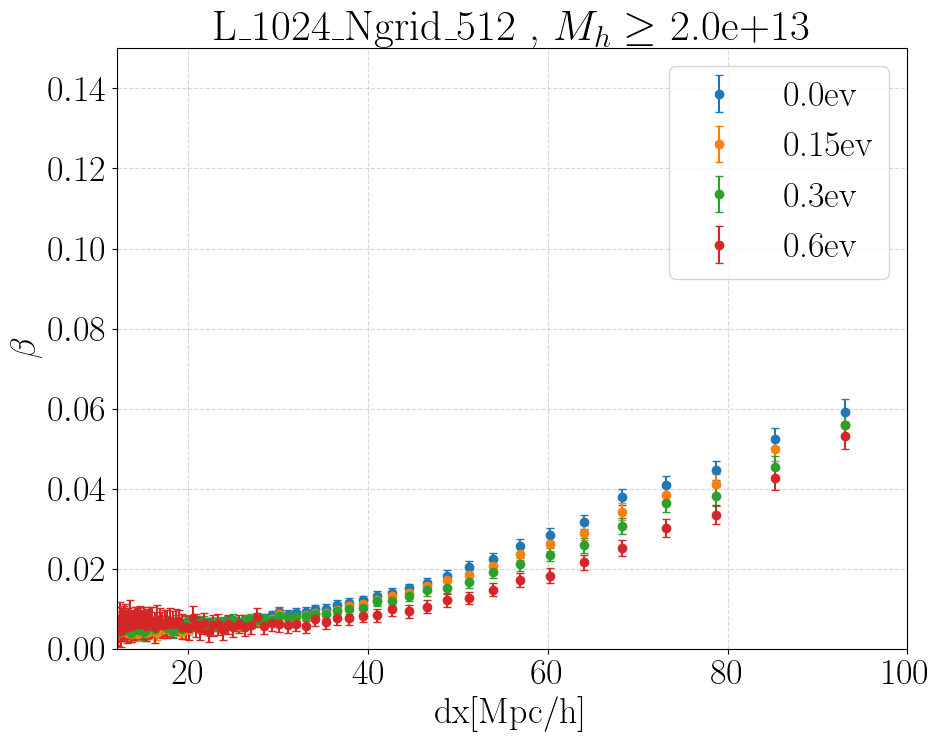

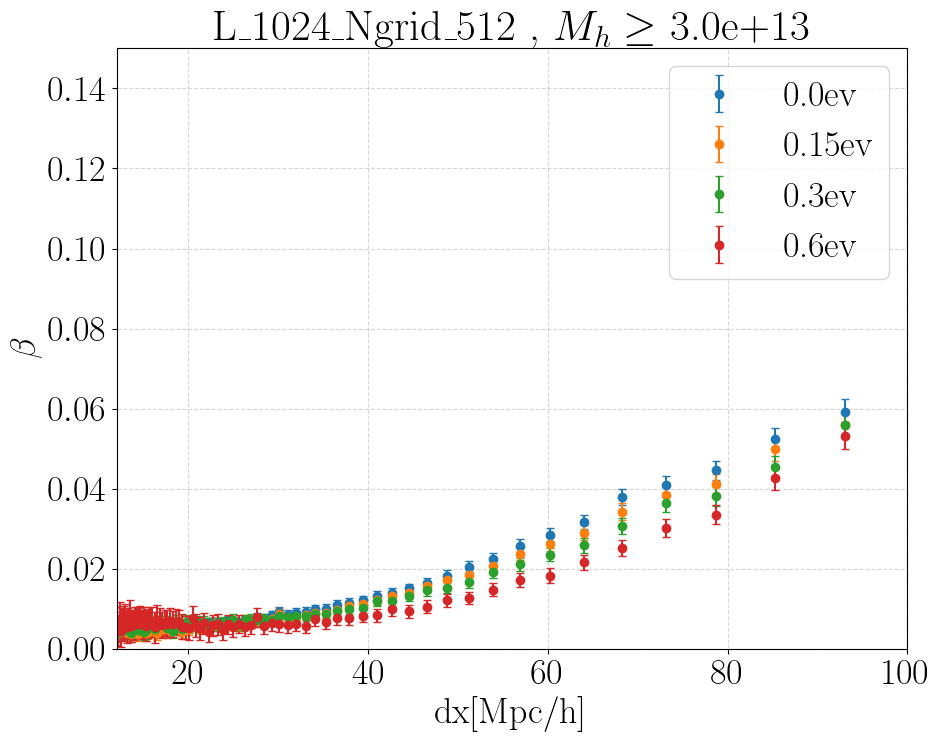

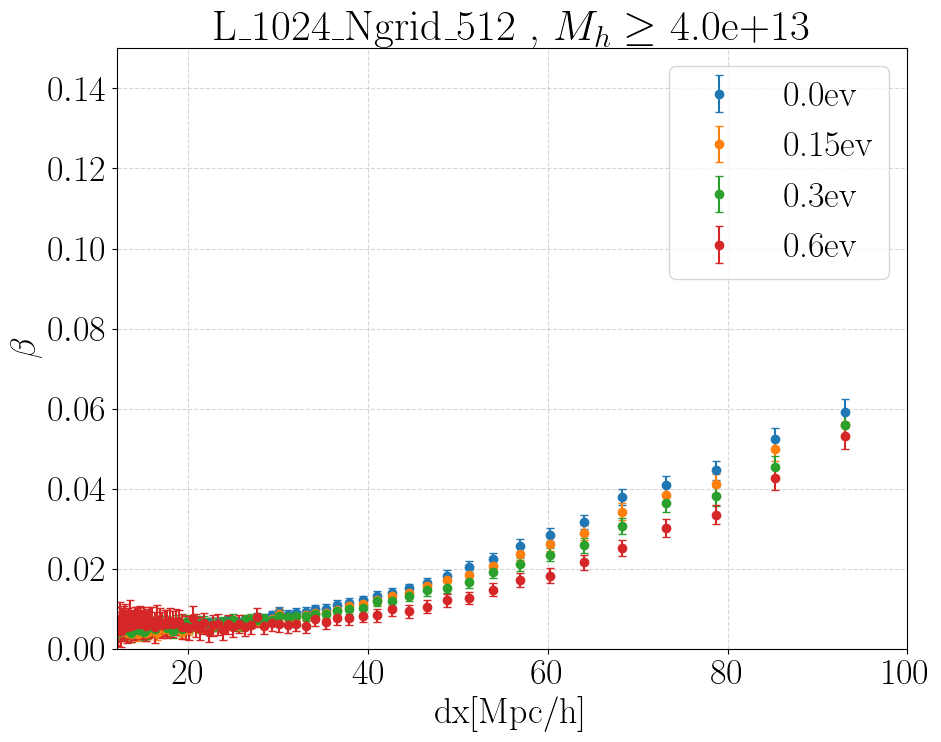

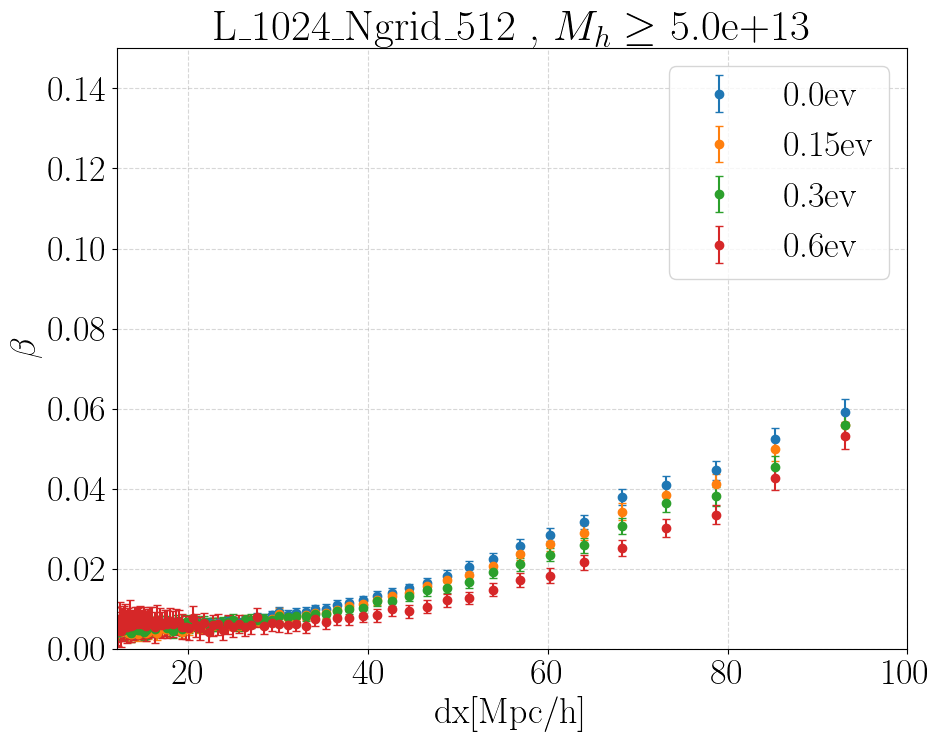

In [8]:

plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

for spec in specs:
    for mass_cut in Mass_cuts[10:14]:
        idx =  Mass_cuts.index(mass_cut)
        plt.figure(figsize=(10,8))
        for sim in sims[:]:

            data_plot=[]
            for ngrid in ngrids:
                dx  = BoxSize/ngrid
                data_plot.append((dx , data[spec][sim][mass_cut][ngrid][0], data[spec][sim][mass_cut][ngrid][1]))
            data_plot = np.array(data_plot)
            plt.errorbar(
            data_plot[:,0],
            data_plot[:,1],
            yerr=data_plot[:,2],
            fmt='o',
            capsize=3,
            label=f"{sim}"
        )
        plt.xlabel('dx[Mpc/h]')
        plt.ylabel(r'$\beta$')
        plt.title(f'{spec} , $M_h \ge$ {Mass_cuts_str[idx][5:]}')
        plt.legend()
        plt.ylim((0, 0.15))
        # plt.xscale('log')
        plt.xlim((12, 100))
        
        plt.grid(True, ls='--', alpha=0.5)
        plt.tight_layout()

# $\Delta \beta$

<Figure size 1000x800 with 0 Axes>

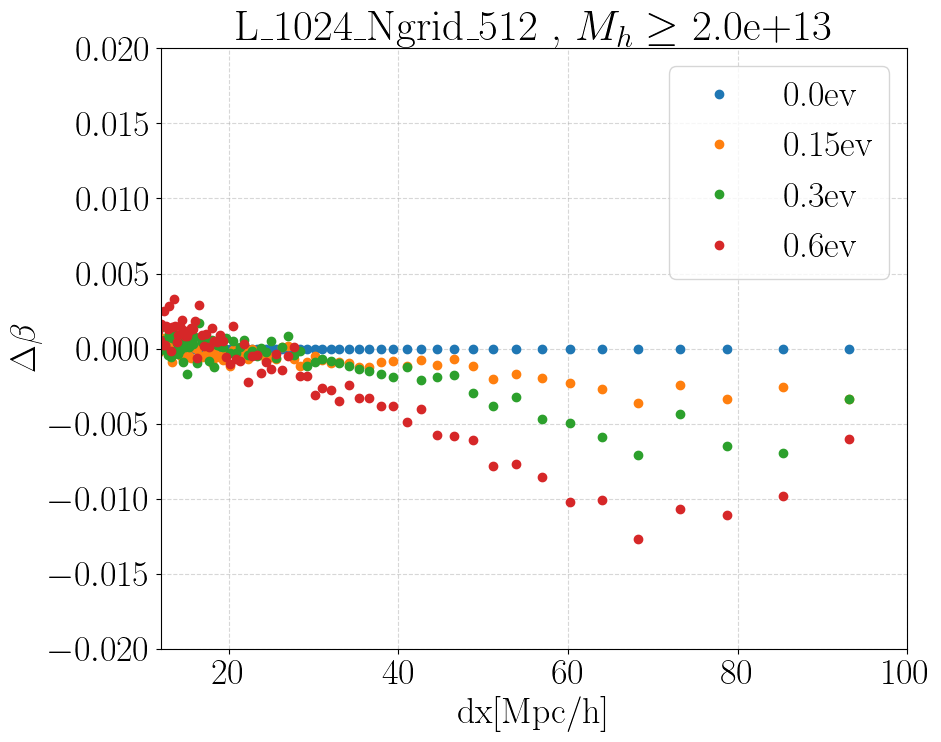

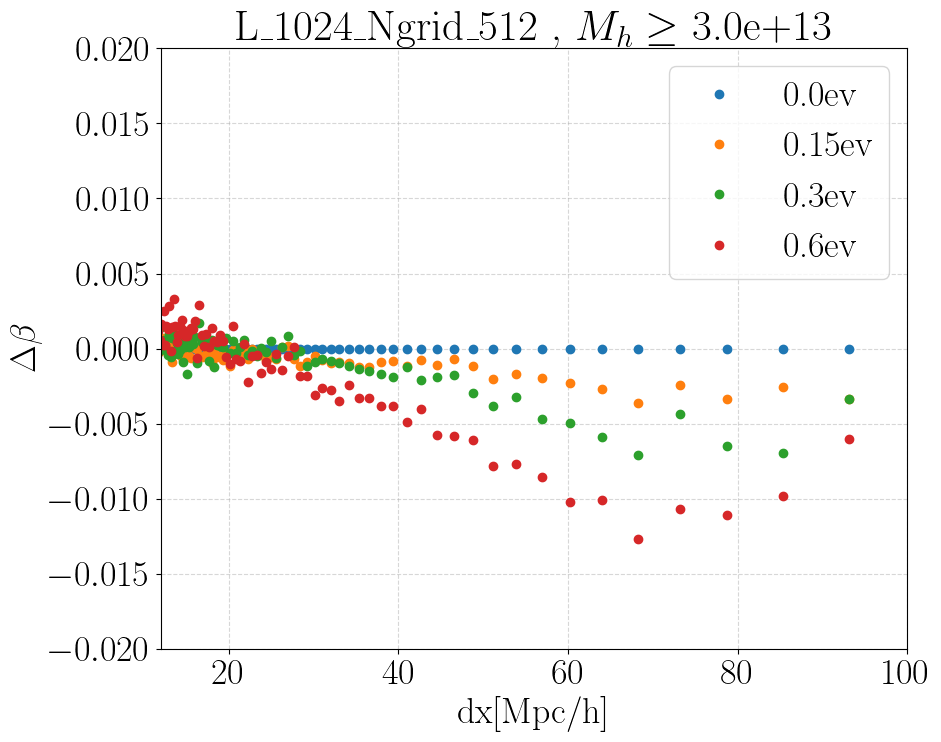

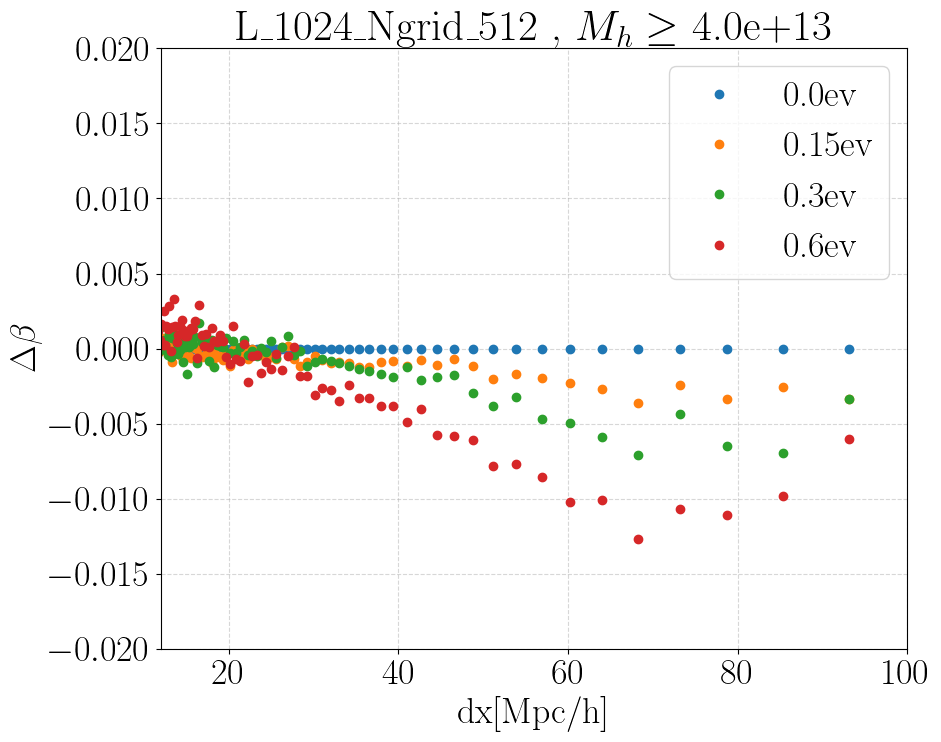

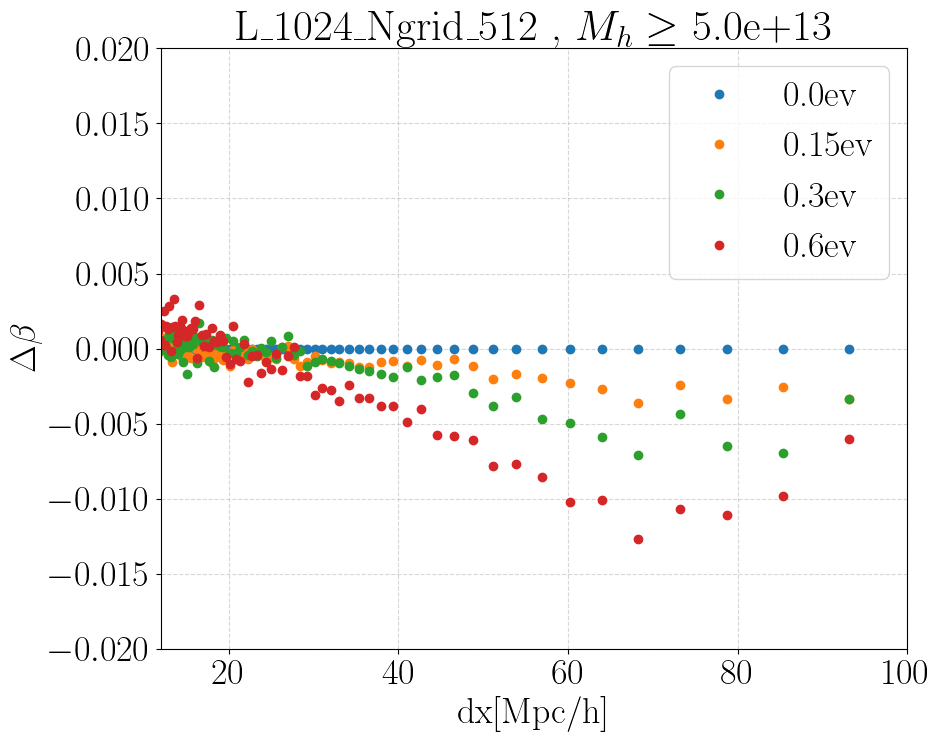

In [14]:
plt.figure(figsize=(10,8))
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

for spec in specs:
    for mass_cut in Mass_cuts[10:14]:
        idx =  Mass_cuts.index(mass_cut)
        plt.figure(figsize=(10,8))
        for sim in sims[:]:
            data_plot=[]
            data_plot_lcdm=[]
            for ngrid in ngrids:
                dx  = BoxSize/ngrid
                data_plot.append((dx , data[spec][sim][mass_cut][ngrid][0], data[spec][sim][mass_cut][ngrid][1]))
                data_plot_lcdm.append((dx , data[spec]["0.0ev"][mass_cut][ngrid][0], data[spec][sim][mass_cut][ngrid][1]))
            data_plot = np.array(data_plot)
            data_plot_lcdm = np.array(data_plot_lcdm)
            plt.plot(
            data_plot[:,0],
            data_plot[:,1]-data_plot_lcdm[:,1], "o",
            label=f"{sim}")
            plt.xlabel('dx[Mpc/h]')
            plt.ylabel(r'$\Delta \beta$')
            plt.title(f'{spec} , $M_h \ge$ {Mass_cuts_str[idx][5:]}')
            plt.legend()
            plt.ylim((-0.02, 0.02))
            # plt.xscale('log')
            plt.xlim((12, 100))
            
            plt.grid(True, ls='--', alpha=0.5)
            plt.tight_layout()

# Loading halos

In [26]:
Mass_cut = 1.e12;
halo_cat = np.loadtxt("./../..//simulations/L_1024_Ngrid_512/0.0ev/output/halos/out_2.list") # Loading the full halo catalogue to loop over each halo
mass_conditions = (halo_cat[:,20]>=Mass_cut)                
halo_cat = halo_cat[mass_conditions]  # applying the mass condition
pos_halos = halo_cat[:,8:11];
vel_halos = halo_cat[:,11:14];
masses = halo_cat[:,20];
biases = bias.haloBias(masses, model = 'sheth01', z = 0.0, mdef = '200m')
f_M_b = (biases + (masses / (1.3 * 1.e14)) ** (0.85))

# Loading density

In [11]:
# field = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_512/0.0ev/halo_mass_2e14//output/data_ngrid_89_sim_0.0ev_L_1024_Ngrid_512_halo_mass_2.0e+14.pickle")

field = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_512/0.0ev/halo_mass_4e13///output/data_ngrid_89_sim_0.0ev_L_1024_Ngrid_512_halo_mass_4.0e+13.pickle")

# Doing interpolation of density and momenta from the grid to the position of particles

In [13]:
BoxSize = np.float32(1024.)

density_interp = np.zeros(pos_halos.shape[0], dtype=np.float32);
P_x_interp = np.zeros(pos_halos.shape[0], dtype=np.float32)
P_y_interp = np.zeros(pos_halos.shape[0], dtype=np.float32)
P_z_interp = np.zeros(pos_halos.shape[0], dtype=np.float32)

field_density = field['sub_box_data']['density'].astype(np.float32)
P_x = field['sub_box_data']['P_x'].astype(np.float32)
P_y = field['sub_box_data']['P_y'].astype(np.float32)
P_z = field['sub_box_data']['P_z'].astype(np.float32)
pos_halos = pos_halos.astype(np.float32)
MASL.CIC_interp(field_density, BoxSize, pos_halos, density_interp)
MASL.CIC_interp(P_x, BoxSize, pos_halos, P_x_interp)
MASL.CIC_interp(P_y, BoxSize, pos_halos, P_y_interp)
MASL.CIC_interp(P_z, BoxSize, pos_halos, P_z_interp)

# Constructing the bulk velocities on the position of particles and computing $v_h - \langle v_h \rangle$
That the velocity interpolated in the position of particles, for when we have only one particle in the cell, agrees with the velocity of particle. We checked the values and they make sense!

In [22]:
v_x_bulk = P_x_interp/density_interp
v_y_bulk = P_y_interp/density_interp
v_z_bulk = P_z_interp/density_interp
v_bulk = np.stack((v_x_bulk, v_y_bulk, v_z_bulk), axis=1)
delta_v = vel_halos - v_bulk  # shape (N, 3)

# Compute the regression

In [47]:
tol = 1e-3
delta_v_norm = np.linalg.norm(delta_v, axis=1)
# Keep only halos where delta_v is significant to skip one halo in the neighbourhood!
mask = delta_v_norm > tol

# Apply the mask to all relevant arrays
delta_v_filtered = delta_v[mask]
v_bulk_filtered = v_bulk[mask]
f_filtered = f_M_b[mask]
X = (f_filtered[:, None] * v_bulk_filtered).reshape(-1)
y = delta_v_filtered.reshape(-1)

XtX = np.dot(X, X)
Xty = np.dot(X, y)
beta = Xty / XtX

residuals = y - beta * X
RSS = np.sum(residuals**2)
n = len(y)
sigma_squared = RSS / (n - 1)
beta_std = np.sqrt(sigma_squared / XtX)